<a href="https://colab.research.google.com/github/LewisT1424/010-MOD006902/blob/main/Week_2/Section_10_Python_Example__Model_Diagnostic_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Section 10 Python example - model diagnostic plots exercise

Model diagnostic plots are essential tools in the evaluation of statistical models. They provide visual insights into how well a model has performed, help identify areas where the model may be lacking, and pinpoint underlying assumptions that may have been violated. This section demonstrates how to create model diagnostic plots in Python using matplotlib and statsmodels, focusing on a linear regression model. These plots will include residuals plots, Q-Q plots for checking normality of residuals, and leverage plots to identify influential observations. Then, it is over to you to use these techniques on two other datasets.

1. Setting Up the Environment:

Ensure Python, matplotlib, statsmodels, and numpy are installed in your environment. If not, you can install them using pip:

In [ ]:
pip install numpy matplotlib statsmodels

2. Importing Required Libraries:

Begin by importing necessary Python libraries for handling data, performing regression, and plotting:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

3. Generating Synthetic Data:

For this example, let’s create a synthetic dataset that represents a simple linear relationship with some noise:

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
x = np.linspace(10, 100, 100)
y = 0.5 * x + np.random.normal(0, 10, size=len(x))

# Create a DataFrame
data = pd.DataFrame({'X': x, 'Y': y})

4. Fitting a Linear Regression Model:

Using statsmodels to fit a linear regression model:

In [ ]:
# Fit model
model = ols('Y ~ X', data=data).fit()

5. Plotting Residuals:

Residual plots are used to assess the homoscedasticity of residuals (constant variance across the range of values).

In [ ]:
# Plot residuals
plt.scatter(data['X'], model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

6. Normality Check with Q-Q Plot:

A Q-Q plot shows if the residuals are normally distributed, which is an assumption of linear regression.

In [ ]:
# Q-Q plot for normality
fig = sm.qqplot(model.resid, line='s')
plt.title('Q-Q plot for residual normality check')
plt.show()

7. Leverage Plot:

Leverage plots help identify influential cases that might have an unduly influence on the model fit.

In [ ]:
from statsmodels.graphics.regressionplots import influence_plot

# Influence plot
fig, ax = plt.subplots(figsize=(8,6))
influence_plot(model, ax=ax)
plt.title('Influence plot')
plt.show()

8. Conclusion:

These diagnostic plots provide critical feedback on the adequacy of the regression model. The residual plot can reveal patterns indicating non-linearity, heteroscedasticity, or outliers. The Q-Q plot checks the assumption that residuals are normally distributed, which is crucial for the validity of many statistical tests. Finally, the leverage plot helps identify influential data points that could disproportionately affect the regression line.

By incorporating these diagnostics into the modeling process, data scientists can better understand their models and make informed decisions about potential modifications or whether additional or alternative analysis is necessary. This enhances the reliability and robustness of their findings, ensuring that conclusions drawn from the data are both valid and actionable.

# Chapter Exercise

Now we know how to evaluate models, and how to use diagnostic plots, revisit some of the earlier datasets we have looked at. Can you the housing.csv and the customer_purchases.csv datasets in the same way.

In [8]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.calibration import calibration_curve

In [9]:
data = pl.read_csv('customer_purchases.csv')

data = data.filter(
    pl.col('age').is_not_null(),
    pl.col('last_purchase').is_not_null()
)

data = data.with_columns(
    pl.when(pl.col('will_purchase_again') == 'no').then(0).otherwise(1).alias('will_purchase_again'),
    pl.col('last_purchase').rank('dense').cast(pl.Int64).alias('last_purchase_encoded'),
)

df = data.to_pandas()
df.head()

,customer_id,age,last_purchase,will_purchase_again,last_purchase_encoded
0,1,56,Home & Garden,0,4
1,2,69,Home & Garden,1,4
2,3,46,Electronics,1,3
3,4,32,Sports,0,5
4,5,60,Beauty,0,1


In [10]:
features = ['age', 'last_purchase_encoded']
target = 'will_purchase_again'

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, test_df = train_df.copy(), test_df.copy()

sk_model = LogisticRegression()
sk_model.fit(train_df[features], train_df[target])
y_pred = sk_model.predict(test_df[features])

majority = max(test_df[target].mean(), 1 - test_df[target].mean())
print('Accuracy:', accuracy_score(test_df[target], y_pred))
print('Baseline (always guess the majority class):', majority)
print('Confusion matrix [[TN, FP], [FN, TP]]:\n', confusion_matrix(test_df[target], y_pred))

Accuracy: 0.48743718592964824
Baseline (always guess the majority class): 0.5175879396984925
Confusion matrix [[TN, FP], [FN, TP]]:
 [[57 46]
 [56 40]]


In [11]:
glm = smf.glm(
    'will_purchase_again ~ age + C(last_purchase)',
    data=train_df,
    family=sm.families.Binomial()
).fit()

print(glm.summary())

# Does the model beat an intercept-only model? (likelihood ratio test)
null = smf.glm('will_purchase_again ~ 1', data=train_df, family=sm.families.Binomial()).fit()
lr_stat = 2 * (glm.llf - null.llf)
df_diff = glm.df_model - null.df_model
print(f'\nLR test: chi2={lr_stat:.2f}, df={df_diff:.0f}, p={stats.chi2.sf(lr_stat, df_diff):.4f}')

train_df['p_hat'] = glm.predict(train_df)          # predicted probabilities
train_df['resid_dev'] = glm.resid_deviance         # deviance residuals
train_df['resid_raw'] = glm.resid_response         # y - p_hat

                  Generalized Linear Model Regression Results                  
Dep. Variable:     will_purchase_again   No. Observations:                  795
Model:                             GLM   Df Residuals:                      789
Model Family:                 Binomial   Df Model:                            5
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -547.21
Date:                 Wed, 07 Oct 2026   Deviance:                       1094.4
Time:                         09:51:38   Pearson chi2:                     795.
No. Iterations:                      4   Pseudo R-squ. (CS):           0.007692
Covariance Type:             nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

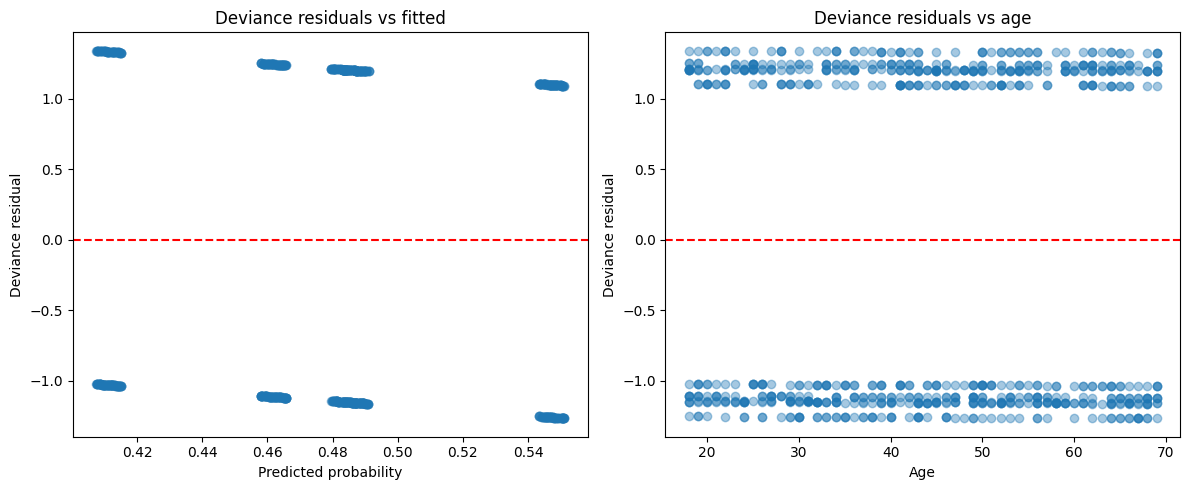

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(train_df['p_hat'], train_df['resid_dev'], alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Deviance residual')
axes[0].set_title('Deviance residuals vs fitted')

axes[1].scatter(train_df['age'], train_df['resid_dev'], alpha=0.4)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Deviance residual')
axes[1].set_title('Deviance residuals vs age')

plt.tight_layout()
plt.show()

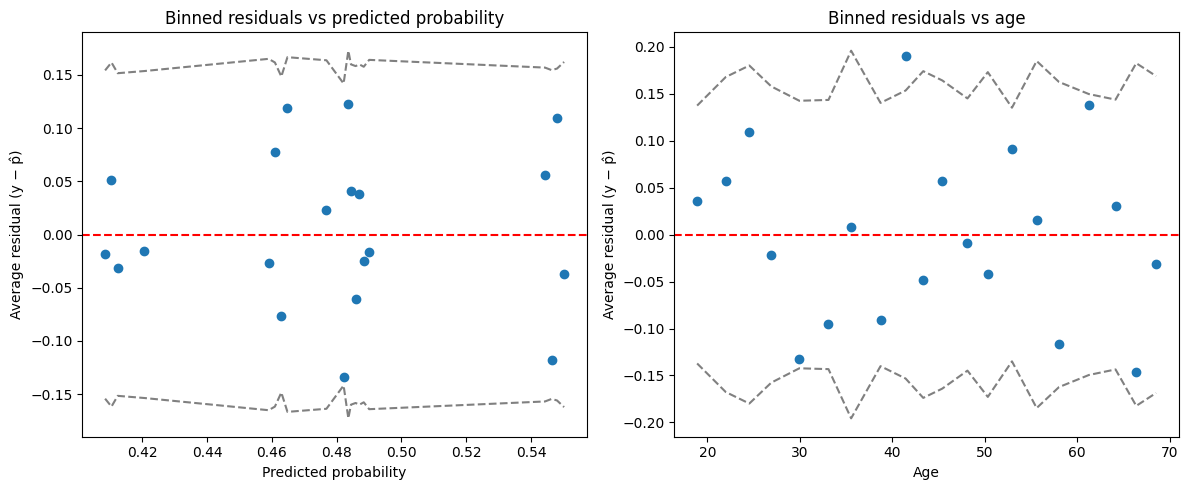

In [13]:
def binned_residuals(x, resid, n_bins=20):
    bins = pd.qcut(x, q=n_bins, duplicates='drop')
    out = (pd.DataFrame({'x': x, 'r': resid})
             .groupby(bins, observed=True)
             .agg(x_mean=('x', 'mean'), r_mean=('r', 'mean'),
                  r_sd=('r', 'std'), n=('r', 'size')))
    out['bound'] = 2 * out['r_sd'] / np.sqrt(out['n'])
    return out

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, label in [(axes[0], 'p_hat', 'Predicted probability'), (axes[1], 'age', 'Age')]:
    b = binned_residuals(train_df[col], train_df['resid_raw'])
    ax.scatter(b['x_mean'], b['r_mean'])
    ax.plot(b['x_mean'], b['bound'], color='grey', linestyle='--')
    ax.plot(b['x_mean'], -b['bound'], color='grey', linestyle='--')
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel(label)
    ax.set_ylabel('Average residual (y − p̂)')
    ax.set_title(f'Binned residuals vs {label.lower()}')
plt.tight_layout()
plt.show()

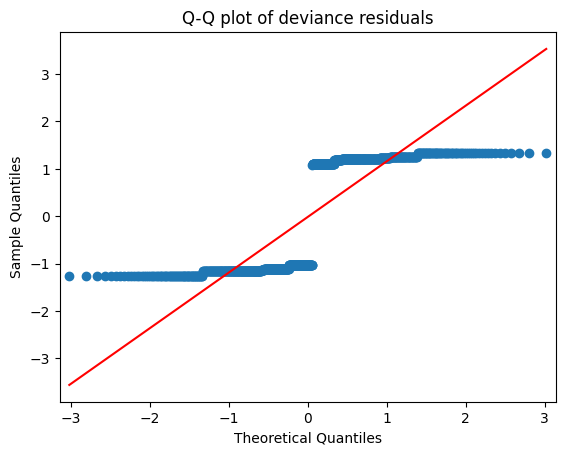

In [14]:
sm.qqplot(train_df['resid_dev'], line='s')
plt.title('Q-Q plot of deviance residuals')
plt.show()

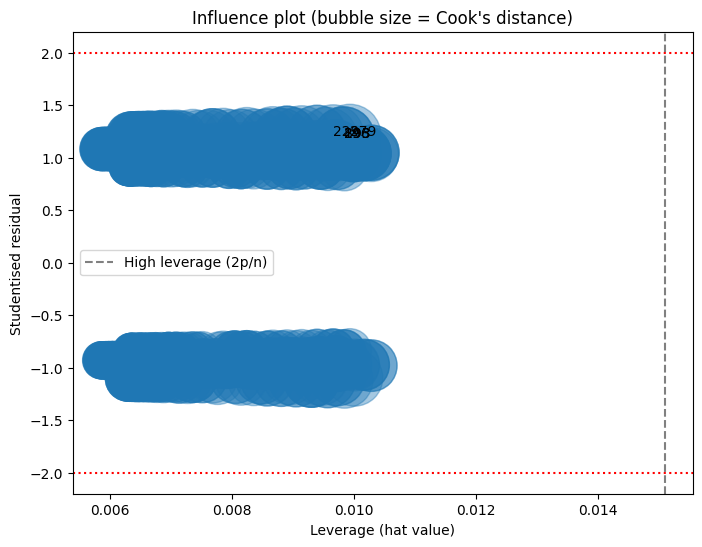

Points with Cook's D > 4/n: 0
     customer_id  age last_purchase  will_purchase_again     p_hat
194          196   69        Beauty                    1  0.415192
889          893   69        Beauty                    1  0.415192
291          293   69        Beauty                    1  0.415192
227          229   19        Beauty                    1  0.407673
277          279   18        Beauty                    1  0.407523


In [15]:
infl = glm.get_influence()
leverage = infl.hat_matrix_diag
stud_resid = infl.resid_studentized
cooks = infl.cooks_distance[0]

n, p = len(train_df), glm.df_model + 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(leverage, stud_resid, s=20 + 2000 * cooks / cooks.max(), alpha=0.4)
ax.axvline(2 * p / n, color='grey', linestyle='--', label='High leverage (2p/n)')
ax.axhline(2, color='red', linestyle=':')
ax.axhline(-2, color='red', linestyle=':')

top = np.argsort(cooks)[-5:]
for i in top:
    ax.annotate(int(train_df['customer_id'].iloc[i]), (leverage[i], stud_resid[i]))

ax.set_xlabel('Leverage (hat value)')
ax.set_ylabel('Studentised residual')
ax.set_title('Influence plot (bubble size = Cook\'s distance)')
ax.legend()
plt.show()

print("Points with Cook's D > 4/n:", (cooks > 4 / n).sum())
print(train_df.iloc[top][['customer_id', 'age', 'last_purchase', target, 'p_hat']])

Test AUC: 0.4799251618122977


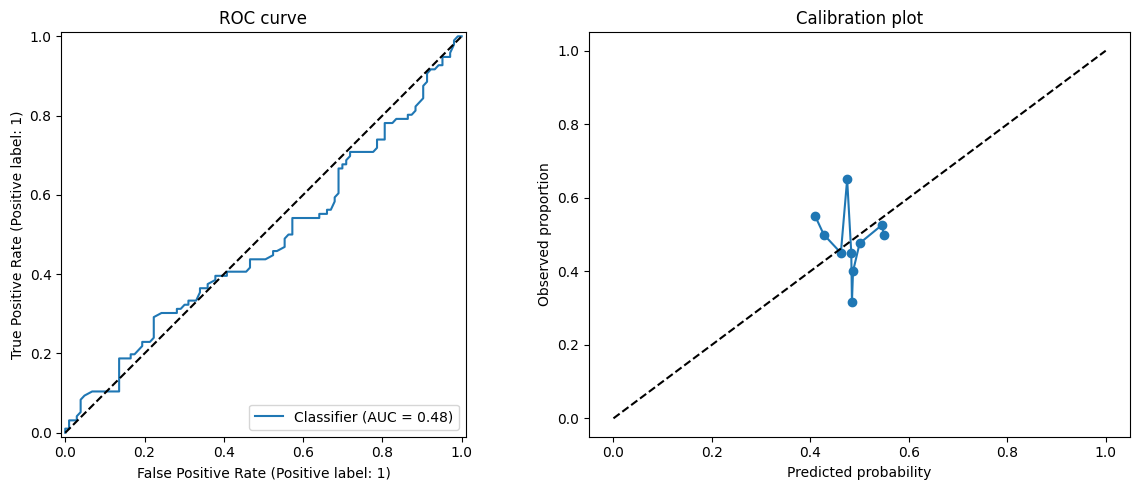

In [16]:
p_test = glm.predict(test_df)
print('Test AUC:', roc_auc_score(test_df[target], p_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(test_df[target], p_test, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC curve')

prob_true, prob_pred = calibration_curve(test_df[target], p_test, n_bins=10, strategy='quantile')
axes[1].plot(prob_pred, prob_true, marker='o')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Observed proportion')
axes[1].set_title('Calibration plot')

plt.tight_layout()
plt.show()